In [ ]:
import os
import numpy as np
import pandas as pd
from glob import glob
from collections import Counter

# ===== 參數設定 =====
DATASET_DIR = "../datasets/pathological_gait_datasets-master/Pathological_Gaits"
OUTPUT_DIR = "../datasets/processed_data"
OUTPUT_FILE = os.path.join(OUTPUT_DIR, "patho50_data_noNorm.npz")  # 改檔名避免覆蓋

SELECTED_JOINTS = [18, 17, 16, 0, 12, 13, 14]
FRAME_THRESHOLD = 60
USE_FRAMES = 50
SKIP_FRAMES = 10

os.makedirs(OUTPUT_DIR, exist_ok=True)

# ===== 讀取 CSV -> (frames, 25, 3) =====
def load_skeleton_csv(file_path):
    df = pd.read_csv(file_path, header=None, sep="\t", engine="python")
    frames = []
    for _, row in df.iterrows():
        row = row.astype(float).values
        row = row[1:]  # 跳過時間戳
        coords = []
        for j in range(25):
            idx = j * 4 + 1
            x, y, z = row[idx:idx+3]
            coords.append([x, y, z])
        frames.append(coords)
    return np.array(frames)  # (frames, 25, 3)

# ===== 主處理流程（無平移正規化） =====
def preprocess_dataset():
    all_data, all_labels, all_subjects = [], [], []

    # 只取 gait type 當分類
    gait_types = sorted(set(os.path.basename(p).split('_')[1].rstrip('0123456789') 
                            for p in glob(f"{DATASET_DIR}/*")))
    label_map = {g: i for i, g in enumerate(gait_types)}

    for clip_dir in glob(f"{DATASET_DIR}/*"):
        parts = os.path.basename(clip_dir).split('_')
        subject_id = parts[0]  # 例如 human01
        gait_type = parts[1].rstrip('0123456789')

        label = label_map[gait_type]

        for csv_file in glob(f"{clip_dir}/*.csv"):
            skel = load_skeleton_csv(csv_file)
            if len(skel) < FRAME_THRESHOLD:
                continue

            # 前 10 幀丟掉，取後面 50 幀
            skel = skel[SKIP_FRAMES:SKIP_FRAMES + USE_FRAMES]

            # 直接取下半身 joints（❌ 不做平移正規化）
            skel = skel[:, SELECTED_JOINTS, :]

            # 轉成 (3, T, V, 1)
            seq = np.transpose(skel, (2, 0, 1))
            seq = seq[..., np.newaxis]

            all_data.append(seq)
            all_labels.append(label)
            all_subjects.append(subject_id)

    all_data = np.array(all_data)
    all_labels = np.array(all_labels)
    all_subjects = np.array(all_subjects)

    # 儲存
    np.savez(OUTPUT_FILE, data=all_data, labels=all_labels, subjects=all_subjects)

    # 印出資料統計
    print(f"✅ 輸出檔案：{OUTPUT_FILE}")
    print(f"資料 shape: {all_data.shape}")
    print(f"標籤 shape: {all_labels.shape}")
    print(f"受試者 shape: {all_subjects.shape}")
    print(f"總 clips 數: {len(all_labels)}")
    print(f"各類別數量: {Counter(all_labels)}")
    print(f"受試者數量: {len(set(all_subjects))} → {set(all_subjects)}")
    print(f"標籤對應：{label_map}")

if __name__ == "__main__":
    preprocess_dataset()


In [ ]:
import numpy as np

# 讀取資料
npz = np.load("../datasets/processed_data/patho50_data_noNorm.npz")
data = npz["data"]
labels = npz["labels"]
subjects = npz["subjects"]

unique_subjects = np.unique(subjects)

for test_sub in unique_subjects:
    # 測試集 index
    test_idx = (subjects == test_sub)
    # 訓練集 index
    train_idx = ~test_idx

    X_train, y_train = data[train_idx], labels[train_idx]
    X_test, y_test = data[test_idx], labels[test_idx]

    print(f"Subject {test_sub} → train: {X_train.shape[0]} | test: {X_test.shape[0]}")

    


Subject human1 → train: 6437 | test: 720
Subject human10 → train: 6437 | test: 720
Subject human2 → train: 6444 | test: 713
Subject human3 → train: 6439 | test: 718
Subject human4 → train: 6470 | test: 687
Subject human5 → train: 6437 | test: 720
Subject human6 → train: 6437 | test: 720
Subject human7 → train: 6438 | test: 719
Subject human8 → train: 6437 | test: 720
Subject human9 → train: 6437 | test: 720



=== 測試 Subject: human1 ===
[Epoch   5] LR: 1.00e-02 | Train Loss: 0.2271 | Train Acc: 92.70%
[Epoch  10] LR: 1.00e-02 | Train Loss: 0.1517 | Train Acc: 95.25%
[Epoch  15] LR: 1.00e-02 | Train Loss: 0.1259 | Train Acc: 95.77%
[Epoch  20] LR: 1.00e-02 | Train Loss: 0.1172 | Train Acc: 96.49%
[Epoch  25] LR: 1.00e-02 | Train Loss: 0.0928 | Train Acc: 97.22%
[Epoch  30] LR: 1.00e-03 | Train Loss: 0.1029 | Train Acc: 96.92%
[Epoch  35] LR: 1.00e-03 | Train Loss: 0.0308 | Train Acc: 99.32%
[Epoch  40] LR: 1.00e-03 | Train Loss: 0.0295 | Train Acc: 99.33%
[Epoch  45] LR: 1.00e-03 | Train Loss: 0.0363 | Train Acc: 99.19%
[Epoch  50] LR: 1.00e-03 | Train Loss: 0.0307 | Train Acc: 99.22%
[Epoch  55] LR: 1.00e-03 | Train Loss: 0.0319 | Train Acc: 99.24%
[Epoch  60] LR: 1.00e-04 | Train Loss: 0.0259 | Train Acc: 99.38%
[Epoch  65] LR: 1.00e-04 | Train Loss: 0.0179 | Train Acc: 99.66%
[Epoch  70] LR: 1.00e-04 | Train Loss: 0.0165 | Train Acc: 99.74%
[Epoch  75] LR: 1.00e-04 | Train Loss: 0.0168 | 

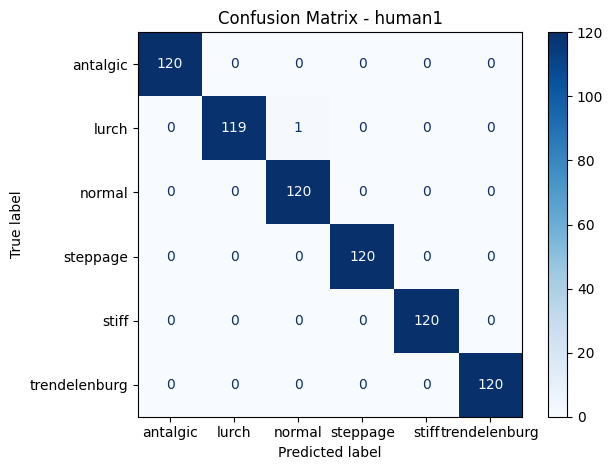

測試集準確率: 99.86% | 測試集 F1-score: 0.9986

=== 測試 Subject: human10 ===
[Epoch   5] LR: 1.00e-02 | Train Loss: 0.2444 | Train Acc: 91.77%
[Epoch  10] LR: 1.00e-02 | Train Loss: 0.1808 | Train Acc: 94.07%
[Epoch  15] LR: 1.00e-02 | Train Loss: 0.1206 | Train Acc: 96.35%
[Epoch  20] LR: 1.00e-02 | Train Loss: 0.1078 | Train Acc: 96.54%
[Epoch  25] LR: 1.00e-02 | Train Loss: 0.1047 | Train Acc: 96.96%
[Epoch  30] LR: 1.00e-03 | Train Loss: 0.0955 | Train Acc: 97.22%
[Epoch  35] LR: 1.00e-03 | Train Loss: 0.0349 | Train Acc: 99.24%
[Epoch  40] LR: 1.00e-03 | Train Loss: 0.0324 | Train Acc: 99.22%
[Epoch  45] LR: 1.00e-03 | Train Loss: 0.0382 | Train Acc: 99.02%
[Epoch  50] LR: 1.00e-03 | Train Loss: 0.0305 | Train Acc: 99.21%
[Epoch  55] LR: 1.00e-03 | Train Loss: 0.0359 | Train Acc: 99.10%
[Epoch  60] LR: 1.00e-04 | Train Loss: 0.0297 | Train Acc: 99.22%
[Epoch  65] LR: 1.00e-04 | Train Loss: 0.0206 | Train Acc: 99.58%
[Epoch  70] LR: 1.00e-04 | Train Loss: 0.0207 | Train Acc: 99.55%
[Epoch  7

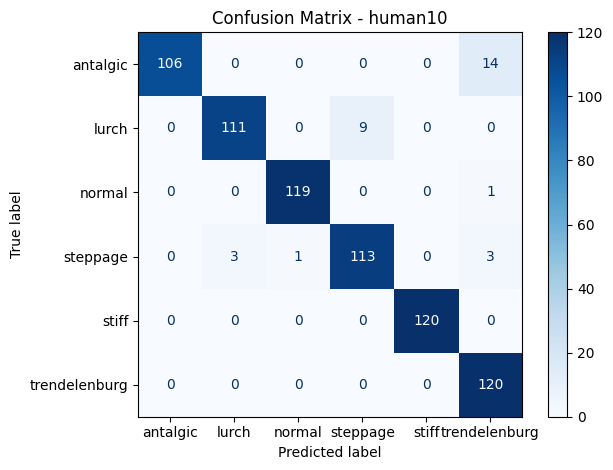

測試集準確率: 95.69% | 測試集 F1-score: 0.9571

=== 測試 Subject: human2 ===
[Epoch   5] LR: 1.00e-02 | Train Loss: 0.2123 | Train Acc: 93.00%
[Epoch  10] LR: 1.00e-02 | Train Loss: 0.1571 | Train Acc: 94.79%
[Epoch  15] LR: 1.00e-02 | Train Loss: 0.1190 | Train Acc: 95.87%
[Epoch  20] LR: 1.00e-02 | Train Loss: 0.1126 | Train Acc: 96.57%
[Epoch  25] LR: 1.00e-02 | Train Loss: 0.1066 | Train Acc: 96.49%
[Epoch  30] LR: 1.00e-03 | Train Loss: 0.1106 | Train Acc: 96.42%
[Epoch  35] LR: 1.00e-03 | Train Loss: 0.0406 | Train Acc: 99.10%
[Epoch  40] LR: 1.00e-03 | Train Loss: 0.0381 | Train Acc: 99.02%
[Epoch  45] LR: 1.00e-03 | Train Loss: 0.0350 | Train Acc: 99.05%
[Epoch  50] LR: 1.00e-03 | Train Loss: 0.0313 | Train Acc: 99.12%
[Epoch  55] LR: 1.00e-03 | Train Loss: 0.0291 | Train Acc: 99.15%
[Epoch  60] LR: 1.00e-04 | Train Loss: 0.0250 | Train Acc: 99.30%
[Epoch  65] LR: 1.00e-04 | Train Loss: 0.0156 | Train Acc: 99.71%
[Epoch  70] LR: 1.00e-04 | Train Loss: 0.0187 | Train Acc: 99.55%
[Epoch  75

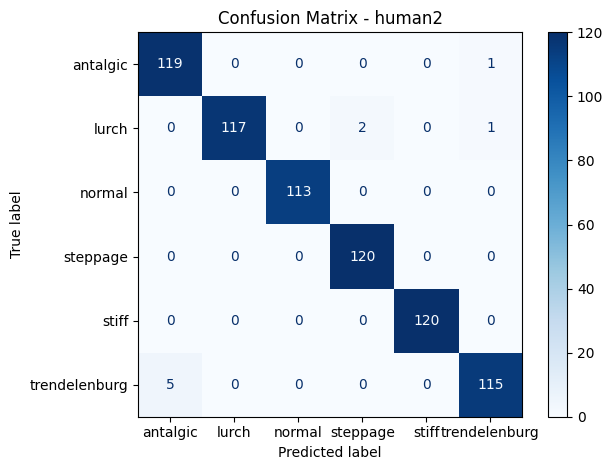

測試集準確率: 98.74% | 測試集 F1-score: 0.9875

=== 測試 Subject: human3 ===
[Epoch   5] LR: 1.00e-02 | Train Loss: 0.2146 | Train Acc: 92.93%
[Epoch  10] LR: 1.00e-02 | Train Loss: 0.1795 | Train Acc: 94.16%
[Epoch  15] LR: 1.00e-02 | Train Loss: 0.1224 | Train Acc: 95.81%
[Epoch  20] LR: 1.00e-02 | Train Loss: 0.1099 | Train Acc: 96.52%
[Epoch  25] LR: 1.00e-02 | Train Loss: 0.1010 | Train Acc: 96.77%
[Epoch  30] LR: 1.00e-03 | Train Loss: 0.1139 | Train Acc: 96.29%
[Epoch  35] LR: 1.00e-03 | Train Loss: 0.0380 | Train Acc: 99.07%
[Epoch  40] LR: 1.00e-03 | Train Loss: 0.0346 | Train Acc: 98.94%
[Epoch  45] LR: 1.00e-03 | Train Loss: 0.0318 | Train Acc: 99.18%
[Epoch  50] LR: 1.00e-03 | Train Loss: 0.0357 | Train Acc: 98.96%
[Epoch  55] LR: 1.00e-03 | Train Loss: 0.0332 | Train Acc: 99.01%
[Epoch  60] LR: 1.00e-04 | Train Loss: 0.0313 | Train Acc: 99.08%
[Epoch  65] LR: 1.00e-04 | Train Loss: 0.0230 | Train Acc: 99.44%
[Epoch  70] LR: 1.00e-04 | Train Loss: 0.0219 | Train Acc: 99.46%
[Epoch  75

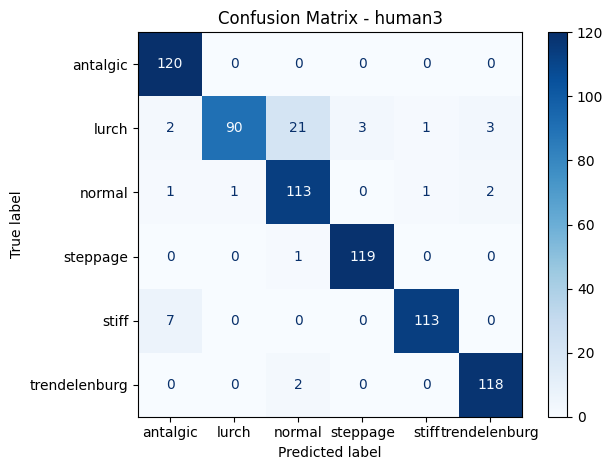

測試集準確率: 93.73% | 測試集 F1-score: 0.9360

=== 測試 Subject: human4 ===
[Epoch   5] LR: 1.00e-02 | Train Loss: 0.2094 | Train Acc: 93.18%
[Epoch  10] LR: 1.00e-02 | Train Loss: 0.1555 | Train Acc: 95.09%
[Epoch  15] LR: 1.00e-02 | Train Loss: 0.1495 | Train Acc: 95.27%
[Epoch  20] LR: 1.00e-02 | Train Loss: 0.1412 | Train Acc: 95.60%
[Epoch  25] LR: 1.00e-02 | Train Loss: 0.1079 | Train Acc: 96.60%
[Epoch  30] LR: 1.00e-03 | Train Loss: 0.1165 | Train Acc: 96.34%
[Epoch  35] LR: 1.00e-03 | Train Loss: 0.0437 | Train Acc: 98.90%
[Epoch  40] LR: 1.00e-03 | Train Loss: 0.0400 | Train Acc: 99.04%
[Epoch  45] LR: 1.00e-03 | Train Loss: 0.0406 | Train Acc: 98.78%
[Epoch  50] LR: 1.00e-03 | Train Loss: 0.0322 | Train Acc: 99.23%
[Epoch  55] LR: 1.00e-03 | Train Loss: 0.0305 | Train Acc: 99.27%
[Epoch  60] LR: 1.00e-04 | Train Loss: 0.0328 | Train Acc: 99.09%
[Epoch  65] LR: 1.00e-04 | Train Loss: 0.0210 | Train Acc: 99.44%
[Epoch  70] LR: 1.00e-04 | Train Loss: 0.0202 | Train Acc: 99.51%
[Epoch  75

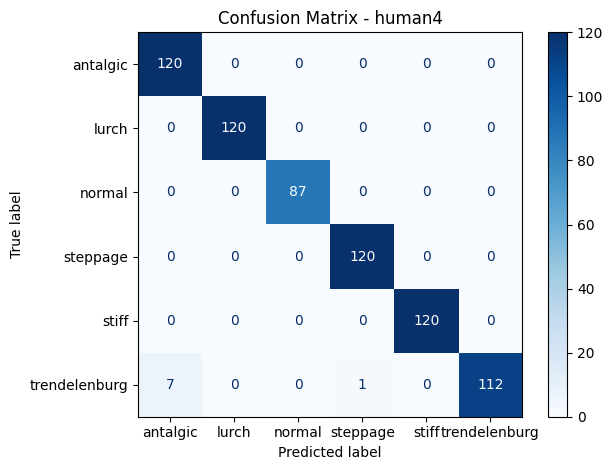

測試集準確率: 98.84% | 測試集 F1-score: 0.9888

=== 測試 Subject: human5 ===
[Epoch   5] LR: 1.00e-02 | Train Loss: 0.2796 | Train Acc: 91.14%
[Epoch  10] LR: 1.00e-02 | Train Loss: 0.1482 | Train Acc: 95.04%
[Epoch  15] LR: 1.00e-02 | Train Loss: 0.1612 | Train Acc: 95.11%
[Epoch  20] LR: 1.00e-02 | Train Loss: 0.0872 | Train Acc: 97.28%
[Epoch  25] LR: 1.00e-02 | Train Loss: 0.1029 | Train Acc: 97.09%
[Epoch  30] LR: 1.00e-03 | Train Loss: 0.1039 | Train Acc: 96.86%
[Epoch  35] LR: 1.00e-03 | Train Loss: 0.0332 | Train Acc: 99.02%
[Epoch  40] LR: 1.00e-03 | Train Loss: 0.0226 | Train Acc: 99.52%
[Epoch  45] LR: 1.00e-03 | Train Loss: 0.0281 | Train Acc: 99.27%
[Epoch  50] LR: 1.00e-03 | Train Loss: 0.0225 | Train Acc: 99.41%
[Epoch  55] LR: 1.00e-03 | Train Loss: 0.0224 | Train Acc: 99.38%
[Epoch  60] LR: 1.00e-04 | Train Loss: 0.0301 | Train Acc: 99.19%
[Epoch  65] LR: 1.00e-04 | Train Loss: 0.0144 | Train Acc: 99.64%
[Epoch  70] LR: 1.00e-04 | Train Loss: 0.0165 | Train Acc: 99.64%
[Epoch  75

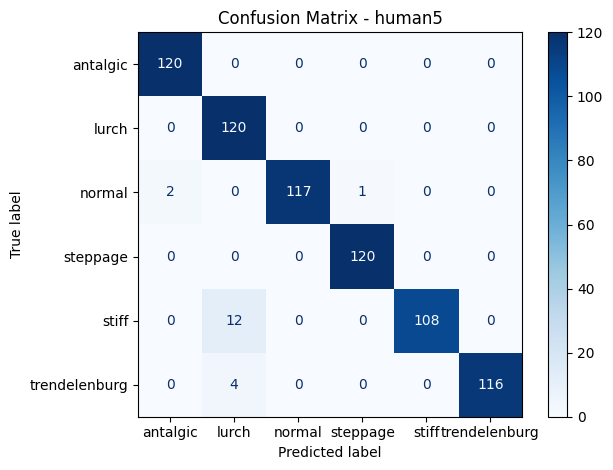

測試集準確率: 97.36% | 測試集 F1-score: 0.9738

=== 測試 Subject: human6 ===
[Epoch   5] LR: 1.00e-02 | Train Loss: 0.2016 | Train Acc: 93.49%
[Epoch  10] LR: 1.00e-02 | Train Loss: 0.1419 | Train Acc: 95.57%
[Epoch  15] LR: 1.00e-02 | Train Loss: 0.1260 | Train Acc: 96.18%
[Epoch  20] LR: 1.00e-02 | Train Loss: 0.1172 | Train Acc: 96.46%
[Epoch  25] LR: 1.00e-02 | Train Loss: 0.1086 | Train Acc: 96.78%
[Epoch  30] LR: 1.00e-03 | Train Loss: 0.0971 | Train Acc: 97.33%
[Epoch  35] LR: 1.00e-03 | Train Loss: 0.0406 | Train Acc: 99.02%
[Epoch  40] LR: 1.00e-03 | Train Loss: 0.0379 | Train Acc: 99.18%
[Epoch  45] LR: 1.00e-03 | Train Loss: 0.0381 | Train Acc: 99.07%
[Epoch  50] LR: 1.00e-03 | Train Loss: 0.0299 | Train Acc: 99.35%
[Epoch  55] LR: 1.00e-03 | Train Loss: 0.0317 | Train Acc: 99.33%
[Epoch  60] LR: 1.00e-04 | Train Loss: 0.0281 | Train Acc: 99.52%
[Epoch  65] LR: 1.00e-04 | Train Loss: 0.0217 | Train Acc: 99.60%
[Epoch  70] LR: 1.00e-04 | Train Loss: 0.0208 | Train Acc: 99.58%
[Epoch  75

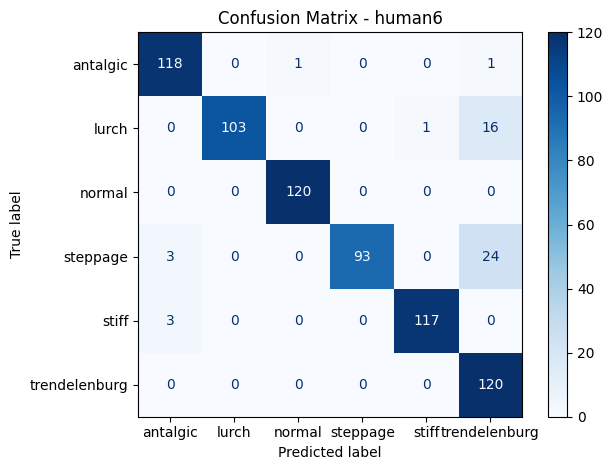

測試集準確率: 93.19% | 測試集 F1-score: 0.9329

=== 測試 Subject: human7 ===
[Epoch   5] LR: 1.00e-02 | Train Loss: 0.2184 | Train Acc: 92.70%
[Epoch  10] LR: 1.00e-02 | Train Loss: 0.1480 | Train Acc: 95.18%
[Epoch  15] LR: 1.00e-02 | Train Loss: 0.1387 | Train Acc: 95.70%
[Epoch  20] LR: 1.00e-02 | Train Loss: 0.1271 | Train Acc: 96.13%
[Epoch  25] LR: 1.00e-02 | Train Loss: 0.1108 | Train Acc: 96.23%
[Epoch  30] LR: 1.00e-03 | Train Loss: 0.1180 | Train Acc: 96.35%
[Epoch  35] LR: 1.00e-03 | Train Loss: 0.0423 | Train Acc: 98.76%
[Epoch  40] LR: 1.00e-03 | Train Loss: 0.0329 | Train Acc: 99.13%
[Epoch  45] LR: 1.00e-03 | Train Loss: 0.0331 | Train Acc: 99.15%
[Epoch  50] LR: 1.00e-03 | Train Loss: 0.0387 | Train Acc: 98.93%
[Epoch  55] LR: 1.00e-03 | Train Loss: 0.0372 | Train Acc: 98.97%
[Epoch  60] LR: 1.00e-04 | Train Loss: 0.0332 | Train Acc: 98.96%
[Epoch  65] LR: 1.00e-04 | Train Loss: 0.0212 | Train Acc: 99.57%
[Epoch  70] LR: 1.00e-04 | Train Loss: 0.0222 | Train Acc: 99.47%
[Epoch  75

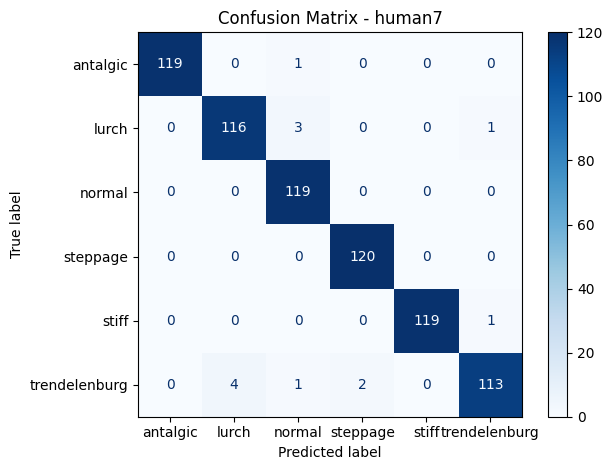

測試集準確率: 98.19% | 測試集 F1-score: 0.9819

=== 測試 Subject: human8 ===
[Epoch   5] LR: 1.00e-02 | Train Loss: 0.1891 | Train Acc: 93.72%
[Epoch  10] LR: 1.00e-02 | Train Loss: 0.1365 | Train Acc: 95.32%
[Epoch  15] LR: 1.00e-02 | Train Loss: 0.1068 | Train Acc: 96.72%
[Epoch  20] LR: 1.00e-02 | Train Loss: 0.0981 | Train Acc: 97.08%
[Epoch  25] LR: 1.00e-02 | Train Loss: 0.1145 | Train Acc: 96.32%
[Epoch  30] LR: 1.00e-03 | Train Loss: 0.0977 | Train Acc: 96.97%
[Epoch  35] LR: 1.00e-03 | Train Loss: 0.0290 | Train Acc: 99.18%
[Epoch  40] LR: 1.00e-03 | Train Loss: 0.0279 | Train Acc: 99.24%
[Epoch  45] LR: 1.00e-03 | Train Loss: 0.0244 | Train Acc: 99.41%
[Epoch  50] LR: 1.00e-03 | Train Loss: 0.0277 | Train Acc: 99.21%
[Epoch  55] LR: 1.00e-03 | Train Loss: 0.0255 | Train Acc: 99.36%
[Epoch  60] LR: 1.00e-04 | Train Loss: 0.0252 | Train Acc: 99.35%
[Epoch  65] LR: 1.00e-04 | Train Loss: 0.0163 | Train Acc: 99.60%
[Epoch  70] LR: 1.00e-04 | Train Loss: 0.0183 | Train Acc: 99.52%
[Epoch  75

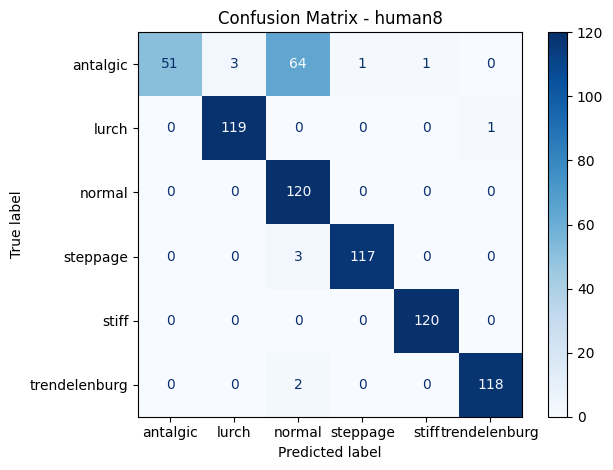

測試集準確率: 89.58% | 測試集 F1-score: 0.8872

=== 測試 Subject: human9 ===
[Epoch   5] LR: 1.00e-02 | Train Loss: 0.2228 | Train Acc: 92.87%
[Epoch  10] LR: 1.00e-02 | Train Loss: 0.1251 | Train Acc: 96.10%
[Epoch  15] LR: 1.00e-02 | Train Loss: 0.1140 | Train Acc: 96.30%
[Epoch  20] LR: 1.00e-02 | Train Loss: 0.1110 | Train Acc: 96.74%
[Epoch  25] LR: 1.00e-02 | Train Loss: 0.0977 | Train Acc: 96.78%
[Epoch  30] LR: 1.00e-03 | Train Loss: 0.0927 | Train Acc: 97.08%
[Epoch  35] LR: 1.00e-03 | Train Loss: 0.0283 | Train Acc: 99.36%
[Epoch  40] LR: 1.00e-03 | Train Loss: 0.0257 | Train Acc: 99.33%
[Epoch  45] LR: 1.00e-03 | Train Loss: 0.0285 | Train Acc: 99.21%
[Epoch  50] LR: 1.00e-03 | Train Loss: 0.0225 | Train Acc: 99.43%
[Epoch  55] LR: 1.00e-03 | Train Loss: 0.0313 | Train Acc: 99.16%
[Epoch  60] LR: 1.00e-04 | Train Loss: 0.0248 | Train Acc: 99.27%
[Epoch  65] LR: 1.00e-04 | Train Loss: 0.0167 | Train Acc: 99.66%
[Epoch  70] LR: 1.00e-04 | Train Loss: 0.0158 | Train Acc: 99.72%
[Epoch  75

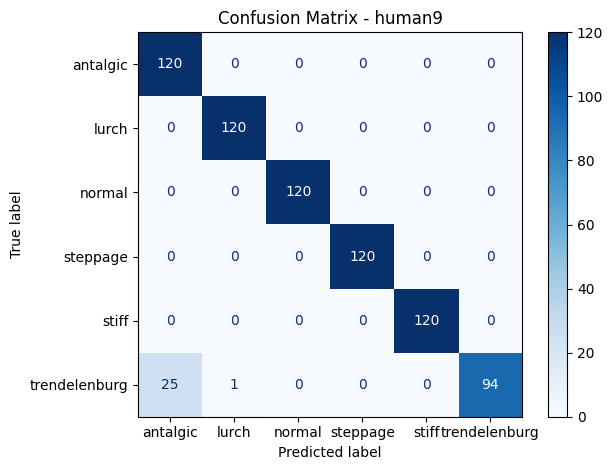

測試集準確率: 96.39% | 測試集 F1-score: 0.9633

=== LOSO 總結 ===
human1: Acc=99.86% | F1=0.9986
human10: Acc=95.69% | F1=0.9571
human2: Acc=98.74% | F1=0.9875
human3: Acc=93.73% | F1=0.9360
human4: Acc=98.84% | F1=0.9888
human5: Acc=97.36% | F1=0.9738
human6: Acc=93.19% | F1=0.9329
human7: Acc=98.19% | F1=0.9819
human8: Acc=89.58% | F1=0.8872
human9: Acc=96.39% | F1=0.9633

平均準確率: 96.16%
最大準確率: 99.86%
最小準確率: 89.58%
標準差: 3.02%

平均 F1-score: 0.9607


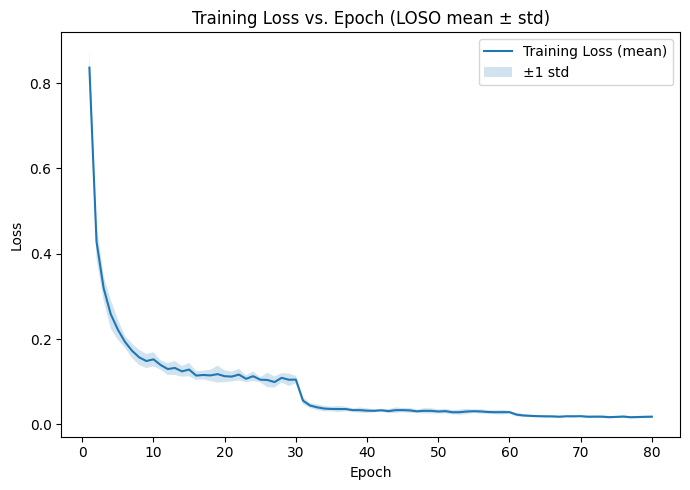

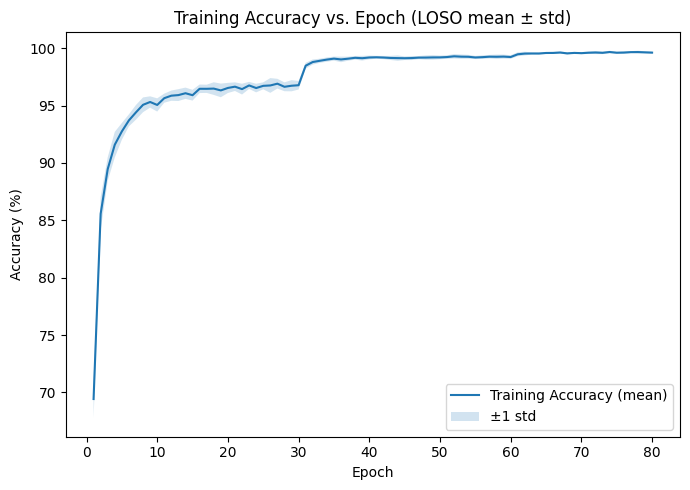

已輸出：
 - 每個 fold 的曲線 CSV：logs/train_curve_<subject>.csv
 - 彙整曲線 CSV：logs/train_curves_loso_mean_std.csv
 - 圖檔：logs/train_loss_loso_mean_std.png / logs/train_acc_loso_mean_std.png


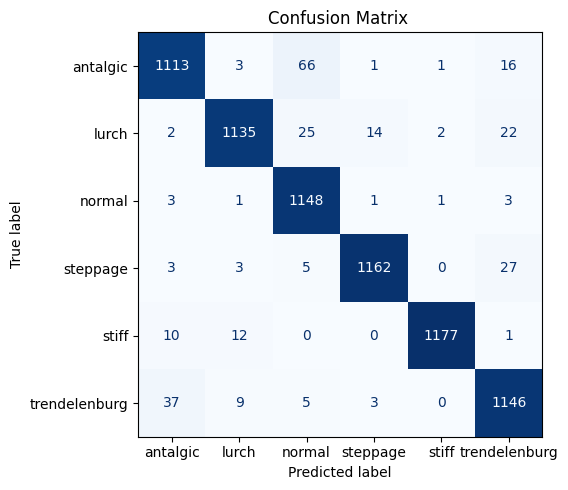

<Figure size 640x480 with 0 Axes>

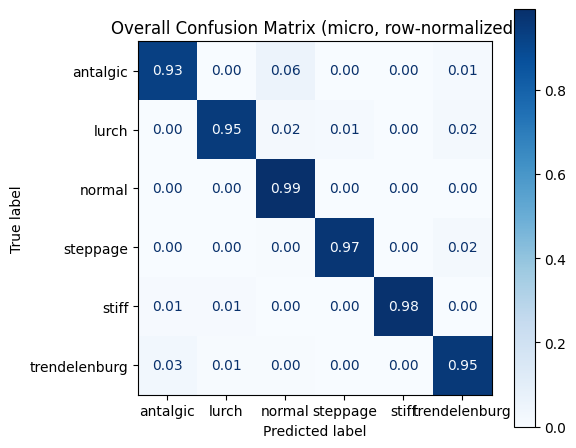

<Figure size 640x480 with 0 Axes>

In [1]:
import os
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import confusion_matrix, f1_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from net.mt_gsgcn_cbam_model  import Model  # 你的模型

# ===================== 可調參數 =====================
DATA_PATH = "../datasets/processed_data/patho50_data_noNorm.npz"
TOTAL_EPOCHS = 80
BATCH_SIZE = 32
LR = 0.01           
WEIGHT_DECAY = 0.001
PRINT_MODE = "fixed"  # "fixed" 或 "adaptive"
PRINT_EVERY = 5      # PRINT_MODE="fixed" 時，每幾個 epoch 列印一次
SHOW_FOLD_CM = True  # 是否顯示每個 fold 的混淆矩陣圖
LOG_DIR = "logs"
os.makedirs(LOG_DIR, exist_ok=True)

# 類別名稱（需與 label 編碼一致）
CLASS_NAMES = ['antalgic','lurch','normal','steppage','stiff','trendelenburg']
NUM_CLASSES = len(CLASS_NAMES)

# ===================== 載入資料 =====================
npz = np.load(DATA_PATH)
data = npz["data"]         # (N, 3, 50, 7, 1)
labels = npz["labels"]     # (N,)
subjects = npz["subjects"] # (N,)
unique_subjects = np.unique(subjects)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ===================== 建立模型 =====================
def build_ags_gcn():
    return Model(in_channels=3, num_class=NUM_CLASSES,
                 graph_args={'layout': 'custom_7joints_spine', 'strategy': 'spatial'},
                 edge_importance_weighting=True)

# ===================== 訓練（回傳逐 epoch 的 loss/acc） =====================
def train_model(model, train_loader, total_epochs=80,
                lr=0.01, weight_decay=1e-3,
                print_mode="fixed", print_every=5):
    """
    回傳: (epoch_losses, epoch_accs) 兩個 list，長度 = total_epochs
    """
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.1)
    criterion = nn.CrossEntropyLoss()

    epoch_losses, epoch_accs = [], []

    def should_print(ep_idx):
        e = ep_idx + 1  # 1-based
        if print_mode == "adaptive":
            if e <= 10:                return True
            if e <= 200 and e % 25==0: return True
            return (e % 50 == 0)
        else:
            return (e % max(1, print_every) == 0)

    for epoch in range(total_epochs):
        model.train()
        total_loss, correct, total = 0.0, 0, 0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad(set_to_none=True)
            out = model(X_batch.to(device))
            loss = criterion(out, y_batch.to(device))
            loss.backward()
            
            # torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            total_loss += loss.item() * y_batch.size(0)
            preds = out.argmax(dim=1)
            correct += (preds.cpu() == y_batch).sum().item()
            total += y_batch.size(0)

        scheduler.step()

        avg_loss = total_loss / max(total, 1)
        acc = correct / max(total, 1) * 100.0
        epoch_losses.append(avg_loss)
        epoch_accs.append(acc)

        if should_print(epoch):
            cur_lr = optimizer.param_groups[0]['lr']
            print(f"[Epoch {epoch+1:>3d}] LR: {cur_lr:.2e} | Train Loss: {avg_loss:.4f} | Train Acc: {acc:.2f}%")

    return epoch_losses, epoch_accs

# ===================== 測試（回傳 preds/trues 與該 fold 的 cm） =====================
def evaluate_model(model, test_loader, subject_name, show_cm=False):
    model.eval()
    preds_all, trues_all = [], []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            logits = model(X_batch.to(device))
            preds = logits.argmax(dim=1).cpu().numpy()
            preds_all.extend(preds)
            trues_all.extend(y_batch.numpy())

    acc = np.mean(np.array(preds_all) == np.array(trues_all)) * 100.0
    f1 = f1_score(trues_all, preds_all, average='macro')

    cm_fold = confusion_matrix(trues_all, preds_all, labels=list(range(NUM_CLASSES)))
    if show_cm:
        disp = ConfusionMatrixDisplay(cm_fold, display_labels=CLASS_NAMES)
        disp.plot(cmap='Blues')
        plt.title(f"Confusion Matrix - {subject_name}")
        plt.tight_layout()
        plt.show()

    return acc, f1, preds_all, trues_all, cm_fold

# ===================== LOSO 實驗 =====================
results = []
all_preds, all_trues = [], []  # 用於「總體（micro）」混淆矩陣
global_cm = np.zeros((NUM_CLASSES, NUM_CLASSES), dtype=np.int64)  # 直接累加各 fold 的計數
loss_curves, acc_curves = [], []  # 收集每個 fold 的訓練曲線

for i, test_sub in enumerate(unique_subjects):
    print(f"\n=== 測試 Subject: {test_sub} ===")

    test_idx = (subjects == test_sub)
    train_idx = ~test_idx

    X_train = torch.tensor(data[train_idx], dtype=torch.float32)  # (N, 3, 50, 7, 1)
    y_train = torch.tensor(labels[train_idx], dtype=torch.long)
    X_test  = torch.tensor(data[test_idx], dtype=torch.float32)
    y_test  = torch.tensor(labels[test_idx], dtype=torch.long)

    train_loader = DataLoader(TensorDataset(X_train, y_train),
                              batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=4, pin_memory=True, persistent_workers=True)
    test_loader  = DataLoader(TensorDataset(X_test,  y_test),
                              batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=4, pin_memory=True, persistent_workers=True)

    model = build_ags_gcn()
    # 訓練，並取回逐 epoch 曲線
    losses, accs = train_model(model, train_loader, total_epochs=TOTAL_EPOCHS,
                               lr=LR, weight_decay=WEIGHT_DECAY,
                               print_mode=PRINT_MODE, print_every=PRINT_EVERY)

    # 存每個 fold 的曲線 CSV
    sub_name = str(test_sub)
    pd.DataFrame({
        "epoch": np.arange(1, TOTAL_EPOCHS + 1),
        "train_loss": losses,
        "train_acc(%)": accs
    }).to_csv(os.path.join(LOG_DIR, f"train_curve_{sub_name}.csv"), index=False)

    loss_curves.append(losses)
    acc_curves.append(accs)

    # 測試並（選擇性）顯示該 fold 混淆矩陣
    acc, f1, preds_fold, trues_fold, cm_fold = evaluate_model(model, test_loader, sub_name, show_cm=SHOW_FOLD_CM)
    results.append((sub_name, acc, f1))
    print(f"測試集準確率: {acc:.2f}% | 測試集 F1-score: {f1:.4f}")

    # micro 用：收集所有測試結果，或直接累加 cm（兩者等價）
    all_preds.extend(preds_fold)
    all_trues.extend(trues_fold)
    global_cm += cm_fold

# ===================== 總結（各 fold 指標） =====================
acc_list = [r[1] for r in results]
f1_list  = [r[2] for r in results]
print("\n=== LOSO 總結 ===")
for sub, acc, f1 in results:
    print(f"{sub}: Acc={acc:.2f}% | F1={f1:.4f}")
print(f"\n平均準確率: {np.mean(acc_list):.2f}%")
print(f"最大準確率: {np.max(acc_list):.2f}%")
print(f"最小準確率: {np.min(acc_list):.2f}%")
print(f"標準差: {np.std(acc_list):.2f}%")
print(f"\n平均 F1-score: {np.mean(f1_list):.4f}")

# ===================== 訓練曲線 LOSO 平均 ± 標準差 =====================
loss_curves = np.array(loss_curves)  # (folds, epochs)
acc_curves  = np.array(acc_curves)   # (folds, epochs)
epochs = np.arange(1, TOTAL_EPOCHS + 1)

mean_loss = loss_curves.mean(axis=0)
std_loss  = loss_curves.std(axis=0)
mean_acc  = acc_curves.mean(axis=0)
std_acc   = acc_curves.std(axis=0)

# 存彙整 CSV（論文製圖方便）
pd.DataFrame({
    "epoch": epochs,
    "train_loss_mean": mean_loss,
    "train_loss_std": std_loss,
    "train_acc_mean(%)": mean_acc,
    "train_acc_std(%)": std_acc
}).to_csv(os.path.join(LOG_DIR, "train_curves_loso_mean_std.csv"), index=False)

# 畫訓練 Loss 曲線
plt.figure(figsize=(7,5))
plt.plot(epochs, mean_loss, label="Training Loss (mean)")
plt.fill_between(epochs, mean_loss - std_loss, mean_loss + std_loss, alpha=0.2, label="±1 std")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.title("Training Loss vs. Epoch (LOSO mean ± std)")
plt.legend(); plt.tight_layout()
plt.savefig(os.path.join(LOG_DIR, "train_loss_loso_mean_std.png"), dpi=300)
plt.show()

# 畫訓練 Accuracy 曲線
plt.figure(figsize=(7,5))
plt.plot(epochs, mean_acc, label="Training Accuracy (mean)")
plt.fill_between(epochs, mean_acc - std_acc, mean_acc + std_acc, alpha=0.2, label="±1 std")
plt.xlabel("Epoch"); plt.ylabel("Accuracy (%)")
plt.title("Training Accuracy vs. Epoch (LOSO mean ± std)")
plt.legend(); plt.tight_layout()
plt.savefig(os.path.join(LOG_DIR, "train_acc_loso_mean_std.png"), dpi=300)
plt.show()

print("已輸出：")
print(f" - 每個 fold 的曲線 CSV：{LOG_DIR}/train_curve_<subject>.csv")
print(f" - 彙整曲線 CSV：{LOG_DIR}/train_curves_loso_mean_std.csv")
print(f" - 圖檔：{LOG_DIR}/train_loss_loso_mean_std.png / {LOG_DIR}/train_acc_loso_mean_std.png")

# ===================== 產生「整體（micro）混淆矩陣」 =====================
micro_cm_from_pairs = confusion_matrix(all_trues, all_preds, labels=list(range(NUM_CLASSES)))
assert (micro_cm_from_pairs == global_cm).all(), "micro_cm 與 global_cm 不一致，請確認 label 對應"

# counts 版
fig, ax = plt.subplots(figsize=(6,5))
ConfusionMatrixDisplay(global_cm, display_labels=CLASS_NAMES).plot(
    cmap='Blues', ax=ax, values_format='d', colorbar=False
)
plt.title("Confusion Matrix ")
plt.tight_layout(); plt.show()
plt.savefig(os.path.join(LOG_DIR, "overall_cm_micro_counts.png"), dpi=300)

# row-normalized 版（每列百分比）
row_sums = global_cm.sum(axis=1, keepdims=True).clip(min=1)
global_cm_row = global_cm / row_sums
fig, ax = plt.subplots(figsize=(6,5))
ConfusionMatrixDisplay(global_cm_row, display_labels=CLASS_NAMES).plot(
    cmap='Blues', ax=ax, values_format='.2f', colorbar=True
)
plt.title("Overall Confusion Matrix (micro, row-normalized)")
plt.tight_layout(); plt.show()
plt.savefig(os.path.join(LOG_DIR, "overall_cm_micro_rowNorm.png"), dpi=300) 
